# Factor exposures and risk-adjusted performance: US Food Products and Insurance

**Setting.** A quantitative fund asks which risk factors two industry portfolios are exposed to, which model explains their returns best, how stable the exposures are, and whether either industry earned an abnormal return.

**Data.** Monthly returns of Kenneth French's 49 industry portfolios and the Fama-French five factors, July 1963 to October 2025.

**What this notebook does.**
- CAPM, Fama-French 3 and 5 factor regressions, coded from the matrix formulas (OLS and Newey-West standard errors), and checked against `statsmodels`.
- Stability: 60-month rolling exposures with confidence bands, Chow test with p-values, a search over break dates, CUSUM.
- Performance: alphas, joint GRS test, Sharpe ratios, behaviour in crises.

Reading note: a factor loading is an exposure, not a return. A negative SMB loading means the portfolio behaves like large caps, not that large firms earned more.

In [1]:
import warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.tsa.stattools import adfuller
from IPython.display import display
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})

## 1. Data

In [2]:
ind = pd.read_csv("data/Portefeuilles_Industries_49.csv", index_col=0); ind.columns = ind.columns.str.strip()
fac = pd.read_csv("data/FamaFrench_5F.csv", index_col=0); fac.columns = fac.columns.str.strip()
for d in (ind, fac):
    d.index = pd.to_datetime(d.index.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
data = ind[["Food", "Insur"]].join(fac, how="inner")
assert (data[["Food", "Insur"]] > -99).all().all()          # -99.99 is the missing-value code in French's files
NAMES = {"Food": "Food Products", "Insur": "Insurance"}
for k in NAMES:
    data[f"{k}_ex"] = data[k] - data["RF"]
FACT = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
T = len(data)
print(f"{T} months, {data.index[0]:%Y-%m} to {data.index[-1]:%Y-%m}. Returns in % per month.")

desc = pd.DataFrame({NAMES[k]: {"mean": data[f"{k}_ex"].mean(), "std": data[f"{k}_ex"].std(), "min": data[f"{k}_ex"].min(), "max": data[f"{k}_ex"].max(),
                                "skewness": stats.skew(data[f"{k}_ex"]), "excess kurtosis": stats.kurtosis(data[f"{k}_ex"]),
                                "Jarque-Bera p": stats.jarque_bera(data[f"{k}_ex"]).pvalue, "ADF p": adfuller(data[f"{k}_ex"])[1]} for k in NAMES}).round(3)
display(desc)
print("Correlation of excess returns with the factors, and between factors:")
display(data[[f"{k}_ex" for k in NAMES] + FACT].corr().round(2))

748 months, 1963-07 to 2025-10. Returns in % per month.


,Food Products,Insurance
mean,0.576,0.633
std,4.324,5.514
min,-18.360,-26.960
max,18.810,26.070
skewness,0.108,-0.116
excess kurtosis,1.910,2.090
Jarque-Bera p,0.000,0.000
ADF p,0.000,0.000


Correlation of excess returns with the factors, and between factors:


,Food_ex,Insur_ex,Mkt-RF,SMB,HML,RMW,CMA
Food_ex,1.00,0.67,0.67,0.11,-0.01,0.11,-0.08
Insur_ex,0.67,1.00,0.74,0.16,0.07,-0.05,-0.12
Mkt-RF,0.67,0.74,1.00,0.28,-0.21,-0.19,-0.35
SMB,0.11,0.16,0.28,1.00,0.01,-0.34,-0.08
HML,-0.01,0.07,-0.21,0.01,1.00,0.09,0.68
RMW,0.11,-0.05,-0.19,-0.34,0.09,1.00,0.00
CMA,-0.08,-0.12,-0.35,-0.08,0.68,0.00,1.00


Both series are stationary and clearly non-normal (fat tails), which is one reason to use robust standard errors.
Note the correlation between HML and CMA: it matters for reading the five-factor model below.

## 2. Estimation from the matrix formulas
OLS: b = (X'X)^-1 X'y. Newey-West covariance with Bartlett weights and L lags:
V = (X'X)^-1 S (X'X)^-1, with S = sum_t e_t^2 x_t x_t' + sum_l w_l sum_t e_t e_{t-l} (x_t x_{t-l}' + x_{t-l} x_t'), w_l = 1 - l/(L+1).

In [3]:
def ols_nw(y, X, L=6):
    """OLS with Newey-West (HAC) standard errors. Returns coefficients, se, t, residuals, R2, adjusted R2."""
    y = np.asarray(y, float); X = np.asarray(X, float); n, k = X.shape
    XtXi = np.linalg.inv(X.T @ X)
    b = XtXi @ X.T @ y
    e = y - X @ b
    Xe = X * e[:, None]
    S = Xe.T @ Xe
    for l in range(1, L + 1):
        G = Xe[l:].T @ Xe[:-l]
        S += (1 - l / (L + 1)) * (G + G.T)
    V = XtXi @ S @ XtXi * n / (n - k)                       # small-sample scaling, as statsmodels does
    se = np.sqrt(np.diag(V))
    r2 = 1 - e @ e / ((y - y.mean()) @ (y - y.mean()))
    return {"b": b, "se": se, "t": b / se, "e": e, "r2": r2, "r2_adj": 1 - (1 - r2) * (n - 1) / (n - k), "n": n, "k": k}

def design(cols, d=data):
    return np.column_stack([np.ones(len(d)), d[cols].values])

# check against statsmodels
chk = sm.OLS(data["Food_ex"], sm.add_constant(data[FACT])).fit(cov_type="HAC", cov_kwds={"maxlags": 6, "use_correction": True})
mine = ols_nw(data["Food_ex"], design(FACT))
print("max |difference| with statsmodels, coefficients:", np.abs(mine["b"] - chk.params.values).max().round(12), "| standard errors:", np.abs(mine["se"] - chk.bse.values).max().round(10))

max |difference| with statsmodels, coefficients: 0.0 | standard errors: 0.0


In [4]:
MODELS = {"CAPM": ["Mkt-RF"], "FF3": ["Mkt-RF", "SMB", "HML"], "FF5": FACT}
def star(t):
    p = 2 * (1 - stats.norm.cdf(abs(t))); return "***" if p < .01 else "**" if p < .05 else "*" if p < .10 else ""
rows = []
for k in NAMES:
    for mname, cols in MODELS.items():
        r = ols_nw(data[f"{k}_ex"], design(cols))
        row = {"industry": NAMES[k], "model": mname, "alpha (%/yr)": f"{12 * r['b'][0]:.2f}{star(r['t'][0])}"}
        for j, c in enumerate(cols, 1):
            row[c] = f"{r['b'][j]:.3f}{star(r['t'][j])}"
        row["adj. R2"] = round(r["r2_adj"], 3); rows.append(row)
reg = pd.DataFrame(rows).fillna(""); reg.to_csv("data/out_regressions.csv", index=False)
print("Newey-West (6 lags) significance: * 10%, ** 5%, *** 1%")
reg

Newey-West (6 lags) significance: * 10%, ** 5%, *** 1%


,industry,model,alpha (%/yr),Mkt-RF,adj. R2,SMB,HML,RMW,CMA
0,Food Products,CAPM,2.25,0.651***,0.451,,,,
1,Food Products,FF3,1.46,0.704***,0.475,-0.133**,0.207***,,
2,Food Products,FF5,-1.42,0.770***,0.545,-0.003,-0.019,0.512***,0.446***
3,Insurance,CAPM,1.03,0.918***,0.552,,,,
4,Insurance,FF3,-0.79,1.000***,0.607,-0.115,0.441***,,
5,Insurance,FF5,-1.51,1.011***,0.610,-0.074,0.416***,0.172,0.035


### Reading the loadings
- **Market.** Food has a beta well below one (defensive); Insurance is close to one.
- **SMB.** A negative loading means the industry co-moves with *large* caps. It says nothing by itself about whether large firms earned more.
- **HML.** A positive loading is a *value tilt*. In the three-factor model both industries load on HML; in the five-factor model the Food loading on HML disappears once RMW and CMA enter. HML and CMA are strongly correlated (see the table above), so part of what looked like a value exposure is an exposure to profitable, conservatively investing firms.
- **RMW, CMA.** Food co-moves with profitable (RMW) and low-investment (CMA) firms. Insurance loads on RMW only weakly and not on CMA.
- **Alphas.** Compare them across models rather than one by one: an alpha that shrinks or changes sign when factors are added was compensation for those factor exposures.

Model choice uses the *adjusted* R2: for Insurance the gain from three to five factors is negligible, for Food it is material.

## 3. Stability of the exposures
### 3.1 Rolling 60-month estimates
Five years balances precision against the ability to see changes. A 30-year window would smooth everything and discard half the sample.

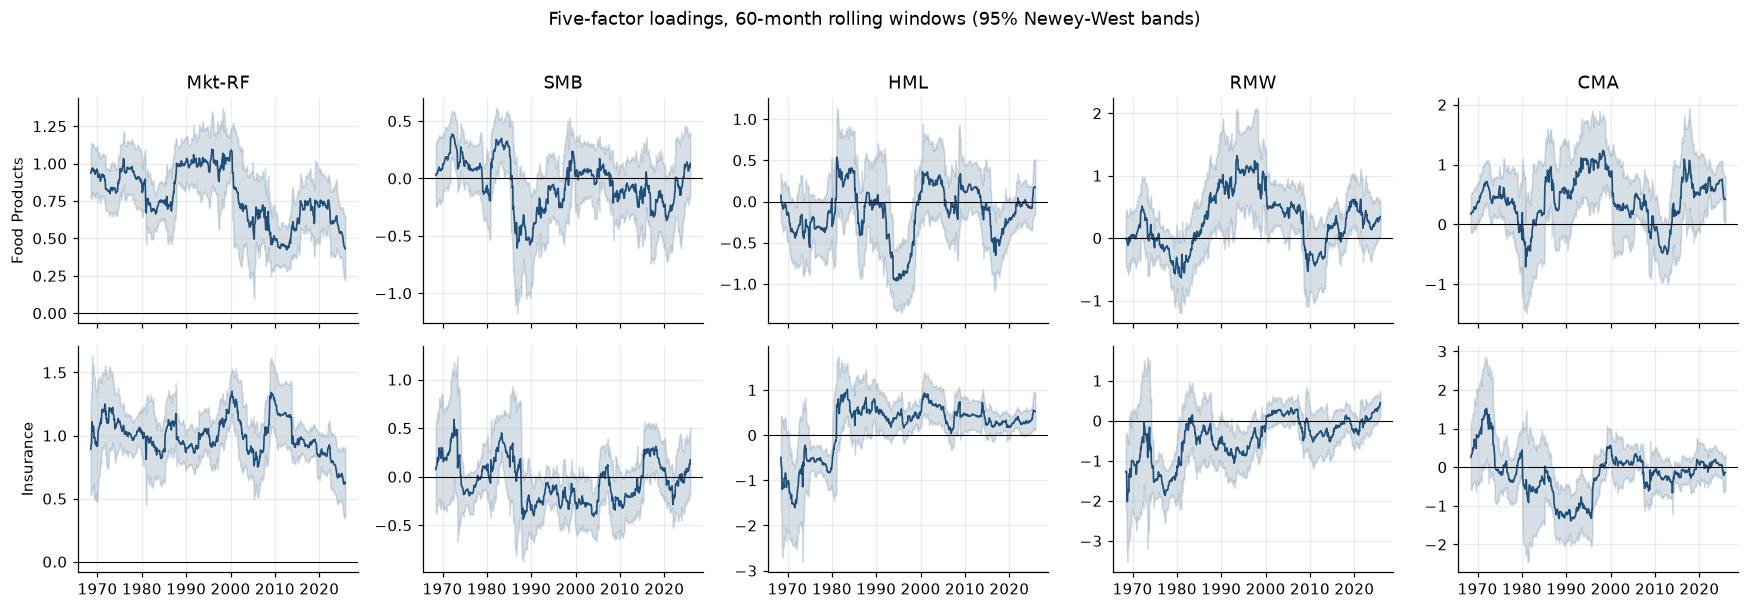

,Food Products,Insurance
Mkt-RF: mean,0.79,1.00
SMB: mean,-0.05,-0.04
HML: mean,-0.13,0.18
RMW: mean,0.29,-0.44
CMA: mean,0.43,-0.17
Mkt-RF: std,0.18,0.14
SMB: std,0.21,0.22
HML: std,0.32,0.57
RMW: std,0.45,0.53
CMA: std,0.39,0.57


In [5]:
W = 60
def rolling(k, cols):
    out = []
    for i in range(W, T + 1):
        d = data.iloc[i - W:i]; r = ols_nw(d[f"{k}_ex"], design(cols, d), L=3)
        out.append([d.index[-1]] + list(r["b"]) + list(r["se"]) + [r["r2_adj"]])
    names = ["alpha"] + cols
    return pd.DataFrame(out, columns=["date"] + names + [f"se_{n}" for n in names] + ["r2_adj"]).set_index("date")
ROLL = {k: rolling(k, FACT) for k in NAMES}

fig, axes = plt.subplots(2, 5, figsize=(16, 5.6), sharex=True)
for i, k in enumerate(NAMES):
    for j, c in enumerate(FACT):
        ax = axes[i, j]; r = ROLL[k]
        ax.plot(r.index, r[c], color="#1f4e79", lw=1.1); ax.fill_between(r.index, r[c] - 1.96 * r[f"se_{c}"], r[c] + 1.96 * r[f"se_{c}"], color="#1f4e79", alpha=.18)
        ax.axhline(0, color="k", lw=.7)
        if i == 0: ax.set_title(c)
        if j == 0: ax.set_ylabel(NAMES[k])
fig.suptitle("Five-factor loadings, 60-month rolling windows (95% Newey-West bands)", y=0.98)
plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.savefig("figures/rolling_loadings.png"); plt.show()

stab = pd.DataFrame({NAMES[k]: {**{f"{c}: mean": ROLL[k][c].mean() for c in FACT}, **{f"{c}: std": ROLL[k][c].std() for c in FACT},
                                "adj. R2: mean": ROLL[k]["r2_adj"].mean(), "adj. R2: std": ROLL[k]["r2_adj"].std()} for k in NAMES}).round(2)
stab.to_csv("data/out_rolling_stability.csv"); stab

### 3.2 Structural breaks
Chow test on the five-factor model at September 2008, with its p-value. Because the date is chosen by the analyst, we also scan all candidate dates (15% trimming) and report the date with the largest F statistic; the maximum of many F tests does not follow the F distribution, so its 5% critical value is obtained here by a residual bootstrap under the no-break model (300 replications). CUSUM tests stability without picking a date.

,industry,Chow F (2008-09),p-value,largest F in scan,at date,bootstrap 5% critical value,break detected,CUSUM p-value
0,Food Products,7.59,0.0000,10.34,1998-12,4.03,True,0.065
1,Insurance,1.67,0.1263,18.37,1979-12,3.95,True,0.946


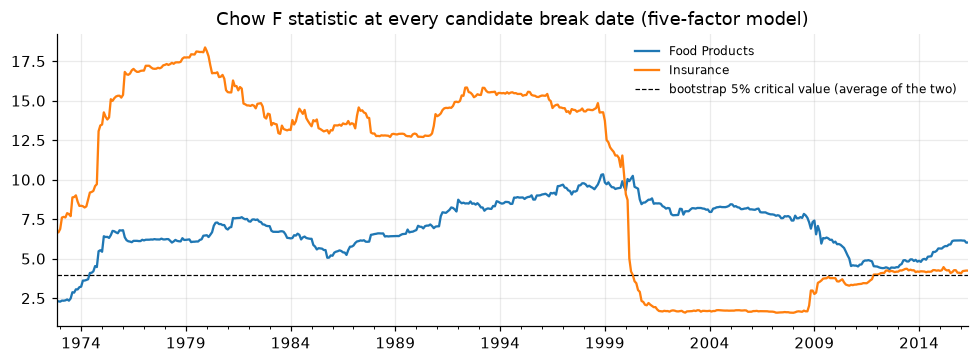

In [6]:
def chow(y, X, i):
    ssr = lambda yy, XX: float(((yy - XX @ np.linalg.lstsq(XX, yy, rcond=None)[0]) ** 2).sum())
    k = X.shape[1]; s0, s1, s2 = ssr(y, X), ssr(y[:i], X[:i]), ssr(y[i:], X[i:])
    F = ((s0 - s1 - s2) / k) / ((s1 + s2) / (len(y) - 2 * k))
    return F, 1 - stats.f.cdf(F, k, len(y) - 2 * k)

X5 = design(FACT); i08 = data.index.get_loc(pd.Timestamp("2008-09-30"))
rng = np.random.default_rng(0); GRID = range(int(.15 * T), int(.85 * T), 6)      # every 6 months, to keep the bootstrap fast
rows = []; SCAN = {}; CRIT = {}
for k in NAMES:
    y = data[f"{k}_ex"].values
    F, p = chow(y, X5, i08)
    lo, hi = int(.15 * T), int(.85 * T)
    scan = pd.Series({data.index[i]: chow(y, X5, i)[0] for i in range(lo, hi)}); SCAN[k] = scan
    fit = ols_nw(y, X5); yhat = X5 @ fit["b"]
    sup = [max(chow(yhat + rng.choice(fit["e"], T, replace=True), X5, i)[0] for i in GRID) for _ in range(300)]
    CRIT[k] = float(np.quantile(sup, .95))
    cus = breaks_cusumolsresid(fit["e"], ddof=X5.shape[1])
    rows.append({"industry": NAMES[k], "Chow F (2008-09)": round(F, 2), "p-value": round(p, 4), "largest F in scan": round(scan.max(), 2),
                 "at date": f"{scan.idxmax():%Y-%m}", "bootstrap 5% critical value": round(CRIT[k], 2), "break detected": bool(scan.max() > CRIT[k]), "CUSUM p-value": round(cus[1], 3)})
brk = pd.DataFrame(rows); brk.to_csv("data/out_breaks.csv", index=False); display(brk)

fig, ax = plt.subplots(figsize=(9, 3.4))
for k in NAMES: SCAN[k].plot(ax=ax, label=NAMES[k])
ax.axhline(np.mean(list(CRIT.values())), color="k", ls="--", lw=.8, label="bootstrap 5% critical value (average of the two)")
ax.set_title("Chow F statistic at every candidate break date (five-factor model)"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig("figures/break_scan.png"); plt.show()

## 4. Performance
### 4.1 Joint test of the alphas (Gibbons, Ross and Shanken 1989)
GRS tests that the alphas of the two industries are jointly zero: F = ((T - N - K)/N) * a' S^-1 a / (1 + m' O^-1 m), with S the residual covariance, m and O the factor means and covariance. It assumes normal i.i.d. residuals, which the data reject, so read it as a complement to the Newey-West t-statistics.

In [7]:
def grs(cols):
    F = data[cols].values; N, K = 2, len(cols); X = design(cols)
    B = np.linalg.lstsq(X, data[[f"{k}_ex" for k in NAMES]].values, rcond=None)[0]
    E = data[[f"{k}_ex" for k in NAMES]].values - X @ B
    a = B[0]; S = E.T @ E / (T - K - 1); mu = F.mean(0); Om = np.atleast_2d(np.cov(F.T, ddof=0))
    stat = (T - N - K) / N * (a @ np.linalg.inv(S) @ a) / (1 + mu @ np.linalg.inv(Om) @ mu)
    return stat, 1 - stats.f.cdf(stat, N, T - N - K)
g = pd.DataFrame({m: dict(zip(["GRS F", "p-value"], np.round(grs(c), 3))) for m, c in MODELS.items()}).T
g.to_csv("data/out_grs.csv"); g

,GRS F,p-value
CAPM,1.259,0.284
FF3,0.910,0.403
FF5,0.799,0.450


### 4.2 Sharpe ratios and crisis periods

In [8]:
def perf(sl, label):
    d = data.loc[sl]
    return {(label, NAMES[k]): {"mean excess return (%/month)": d[f"{k}_ex"].mean(), "volatility (%/month)": d[f"{k}_ex"].std(),
                                "annualised Sharpe": np.sqrt(12) * d[f"{k}_ex"].mean() / d[f"{k}_ex"].std(), "worst month (%)": d[f"{k}_ex"].min()} for k in NAMES}
P = {}
for sl, lab in [(slice(None), "Full sample"), (slice("2007-12", "2009-06"), "2007-12 to 2009-06"), (slice("2020-02", "2020-04"), "2020-02 to 2020-04"), (slice("2022-01", "2022-12"), "2022")]:
    P.update(perf(sl, lab))
mk = data["Mkt-RF"]; print("Market annualised Sharpe, full sample:", round(np.sqrt(12) * mk.mean() / mk.std(), 3))
pf = pd.DataFrame(P).T.round(2); pf.to_csv("data/out_performance.csv"); pf

Market annualised Sharpe, full sample: 0.463


mean excess return (%/month)  \
Full sample        Food Products                          0.58   
                   Insurance                              0.63   
2007-12 to 2009-06 Food Products                         -0.83   
                   Insurance                             -3.50   
2020-02 to 2020-04 Food Products                         -1.72   
                   Insurance                             -3.35   
2022               Food Products                          0.56   
                   Insurance                              0.62   

                                  volatility (%/month)  annualised Sharpe  \
Full sample        Food Products                  4.32               0.46   
                   Insurance                      5.51               0.40   
2007-12 to 2009-06 Food Products                  5.55              -0.52   
                   Insurance                     11.12              -1.09   
2020-02 to 2020-04 Food Products                  9.30              -0.64   
                   Insurance                     13.32              -0.87   
2022               Food Products                  4.60               0.42   
                   Insurance                      4.93               0.44   

                                  worst month (%)  
Full sample        Food Products           -18.36  
                   Insurance               -26.96  
2007-12 to 2009-06 Food Products           -11.06  
                   Insurance               -26.96  
2020-02 to 2020-04 Food Products            -9.43  
                   Insurance               -12.89  
2022               Food Products            -7.92  
                   Insurance                -4.66

## 5. Conclusions
The conclusions are in the README of this folder. Limits: two portfolios only, standard factors, a 62-year sample over which the industries themselves changed, and GRS relies on normality.